In [ ]:
# check which directory i'm using
#import sys
#sys.executable

In [ ]:
# install LIANA
#!{sys.executable} -m pip install liana

In [ ]:
### Liana provides differnet statistical methods to infer ligand-receptor interactions from single cell transcriptomics
## using prior knowledge

In [1]:
## loading packages
# import liana
import liana as li
# needed for visualization and toy data
import scanpy as sc

In [2]:
## loading the data
# In the most general case, liana’s ligand-receptor methods use anndata objects with processed single-cell transcriptomics data, 
# with pre-defined cell labels (identities), to infer ligand-receptor interactions among all pairs of cell identities.
adata = sc.read_h5ad("/Users/ogjaime/Desktop/CellRank/krabd28/krabd28.h5ad")

In [3]:
adata.obs

,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,celltype
AAACCCAAGATACGAT-1,1904,1904,2814.0,13.0,0.461976,7,NPC3
AAACCCAAGCACACCC-1,1948,1948,2940.0,8.0,0.272109,3,NPC2
AAACCCAAGCCTGAGA-1,3221,3220,6083.0,24.0,0.394542,0,SclPC
AAACCCACAAAGCTAA-1,4324,4324,9674.0,113.0,1.168079,5,Mitotic NPC
AAACCCACACAGCTTA-1,3804,3804,7202.0,22.0,0.305471,7,NPC3
...,...,...,...,...,...,...,...
TTTGTTGCAGGCTATT-1,2551,2550,4351.0,21.0,0.482648,7,NPC3
TTTGTTGGTTTACGTG-1,1422,1422,1825.0,11.0,0.602740,2,NEPC
TTTGTTGTCCACGAAT-1,4499,4499,9708.0,80.0,0.824063,1,NPC1
TTTGTTGTCCTCATAT-1,1885,1885,2929.0,11.0,0.375555,6,SMPC


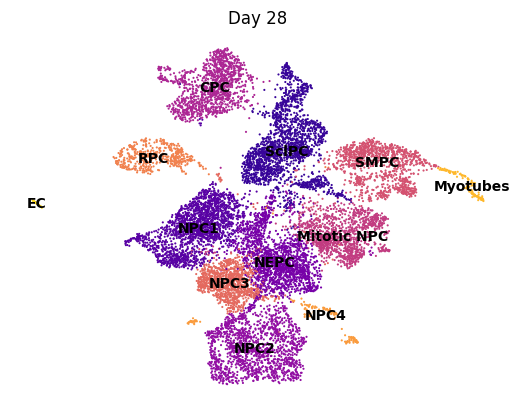

In [4]:
sc.pl.umap(adata, color='celltype', title='Day 28', frameon=False, legend_loc='on data')

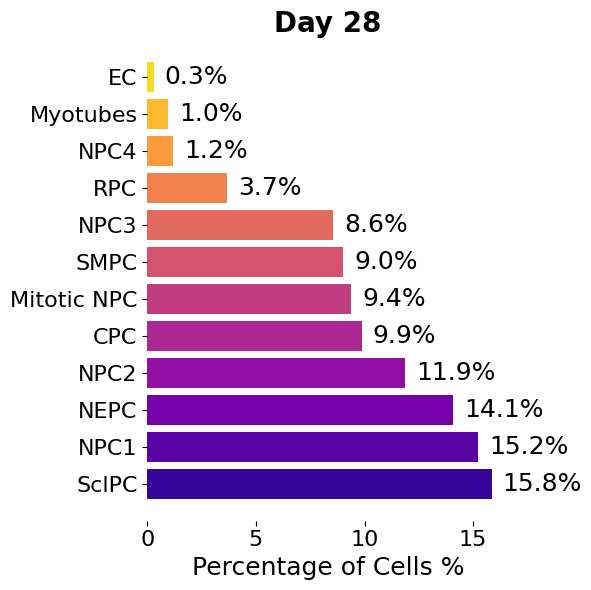

In [5]:
import matplotlib.pyplot as plt
import scanpy as sc

# Ensure cluster counts are sorted
cluster_counts = adata.obs['celltype'].value_counts(normalize=True) * 100
cluster_counts = cluster_counts.sort_index()  # ensures consistent order

# Get colors from your UMAP palette
cluster_colors_dict = dict(zip(adata.obs['celltype'].cat.categories, adata.uns['celltype_colors']))
colors = [cluster_colors_dict[ct] for ct in cluster_counts.index]

# Create horizontal bar plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.barh(
    cluster_counts.index.astype(str),
    cluster_counts,
    color=colors  # matching UMAP colors
)

# Add percentage labels
for i, val in enumerate(cluster_counts.values):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=18)

# Add labels and title
ax.set_xlabel('Percentage of Cells %', fontsize=18)
#ax.set_ylabel('Cell Type', fontsize=16)
ax.set_title('Day 28', fontsize=20, fontweight='bold')
ax.tick_params(axis='both', labelsize=16)

# --- Remove all spines (boxed border) ---
for spine in ax.spines.values():
    spine.set_visible(False)


plt.tight_layout()
plt.show()


In [ ]:
### renaming categories
#adata.obs['celltype'] = adata.obs['celltype'].cat.rename_categories({
    #'CGC': 'MSC', 
    #'MSC': 'SclPC',
    #'MC': 'CPC',
    #'Mitotic MC': 'P_CPC',
#})
#adata.obs['celltype'].cat.categories

In [ ]:
## Use liana with all features (genes) for which we have enough counts
## for that reason check where your expression data lives
#adata.X   # usually the main processed matrix

In [ ]:
#adata.raw # optional, often used to store original normalized counts

In [ ]:
# the adata.raw.X contains the log1p-transformed counts, unscaled, which is what LIANA expects

In [ ]:
# Use the expression matrix stored in adata.raw
#expr_matrix = adata.raw.X

In [6]:
adata.raw.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 33196738 stored elements and shape (12868, 22360)>

In [7]:
# methods
li.mt.show_methods()

,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...
0,scSeqComm,inter_score,None,"Baruzzo, G., Cesaro, G., Di Camillo, B. 2022. ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."


In [8]:
# import liana's rank_aggregate
# rank_aggregate combines the scores of multiple methods
from liana.mt import rank_aggregate

In [9]:
# Get an aggregate of ligand-receptor scores from multiple methods.
?rank_aggregate.__call__

Signature:
rank_aggregate.__call__(
    adata: 'an.AnnData | MuData',
    groupby: 'str',
    resource_name: 'str' = 'consensus',
    expr_prop: 'float' = 0.1,
    min_cells: 'int' = 5,
    groupby_pairs: 'DataFrame | None' = None,
    base: 'float' = np.float64(2.718281828459045),
    aggregate_method: 'str' = 'rra',
    consensus_opts: 'list | None' = None,
    return_all_lrs: 'bool' = False,
    key_added: 'str' = 'liana_res',
    use_raw: 'bool | None' = True,
    layer: 'str | None' = None,
    de_method: 'str' = 't-test',
    n_perms: 'int' = 1000,
    seed: 'int' = 1337,
    n_jobs: 'int' = 1,
    resource: 'DataFrame | None' = None,
    interactions: 'list | None' = None,
    mdata_kwargs: 'dict | None' = None,
    inplace: 'bool' = True,
    verbose: 'bool | None' = False,
)
Docstring:
Get an aggregate of ligand-receptor scores from multiple methods.

Parameters
----------
adata
    Annotated data object.
groupby
    Key to be used for grouping.
resource_name
    Name of the r

In [ ]:
#### Example Run

In [10]:
# import all individual methods
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

In [ ]:
###### Rank Aggregate
# Liana also provides a consensus that integrates the predictions of individual methods. this is done by ranking and aggregating (RRA) 
# the ligand-receptor interaction prediction from all methods

In [11]:
# Run rank_aggregate
li.mt.rank_aggregate(adata, 
                     groupby='celltype',
                     resource_name='consensus',
                     expr_prop=0.1,
                     verbose=True)

Using resource `consensus`.
Using `.raw`!
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
5 features of mat are empty, they will be removed.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.12 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 12868 samples and 1605 features
Assuming that counts were `natural` log-normalized!


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/liana/method/sc/_liana_pipe.py:270: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/liana/method/sc/_liana_pipe.py:275: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/liana/method/sc/_liana_pipe.py:278: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.


Running CellPhoneDB


100%|████████████████████████████████████████████████| 1000/1000 [00:06<00:00, 164.65it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [12]:
## look at the first set of data
adata.uns['liana_res'].head()

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
30437,NPC1,NPC2,SLIT2,DCC,3.052280,0.0,9.314048,1.164850,1.843270,0.040012,0.949417,0.001218,2.140483e-09
27222,NPC1,CPC,SLIT2,ROBO2,2.901257,0.0,8.406811,1.051426,1.911799,0.029749,0.946899,0.005882,8.561845e-09
32534,NPC1,SMPC,SLIT2,ROBO1,2.774845,0.0,7.647417,0.998090,1.420080,0.023370,0.944468,0.006722,1.926395e-08
8152,EC,NPC2,APP,DCC,2.647767,0.0,6.805325,1.163715,1.663391,0.035711,0.941328,0.002278,3.424668e-08
41079,NPC3,NPC2,SLIT2,DCC,2.644435,0.0,6.784661,0.823555,1.306861,0.029146,0.941244,0.006536,5.350988e-08


In [13]:
## look at the rank aggreagate features
rank_aggregate.describe()

Rank_Aggregate returns `magnitude_rank`, `specificity_rank`. magnitude_rank and specificity_rank respectively represent an aggregate of the `magnitude`- and `specificity`-related scoring functions from the different methods.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


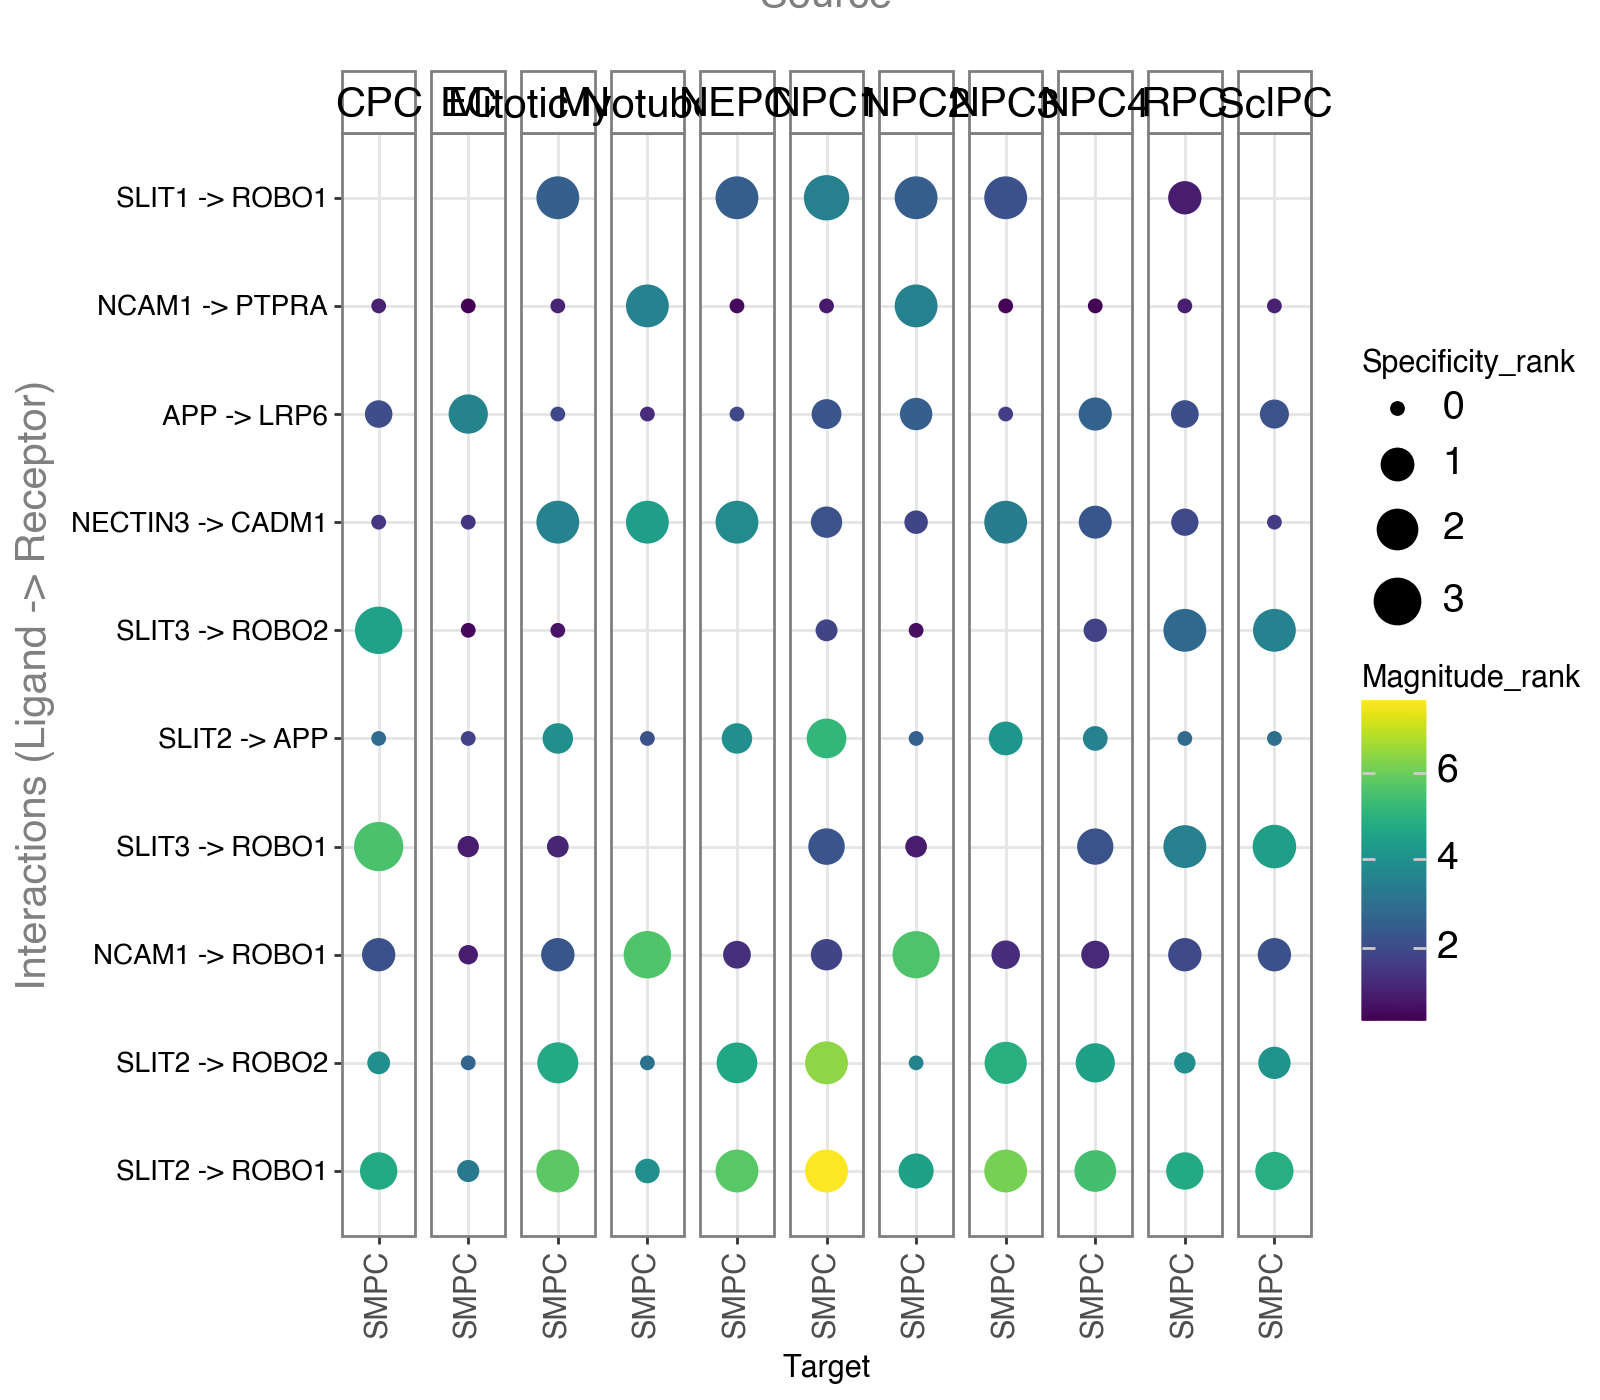

In [14]:
# DOTPLOT shows the most 'relevant' interactions ordered to the magnitude rank results from the aggregated rank.
li.pl.dotplot(adata = adata, 
              colour='magnitude_rank',
              size='specificity_rank',
              inverse_size=True,
              inverse_colour=True,
              source_labels=['SclPC', 'NPC1', 'NEPC', 'NPC2', 'CPC', 'Mitotic NPC', 'NPC3', 'RPC', 'NPC4', 'Myotubes', 'EC'],
              target_labels=['SMPC'],
              top_n=10, 
              orderby='magnitude_rank',
              orderby_ascending=True,
              figure_size=(8, 7)
             )

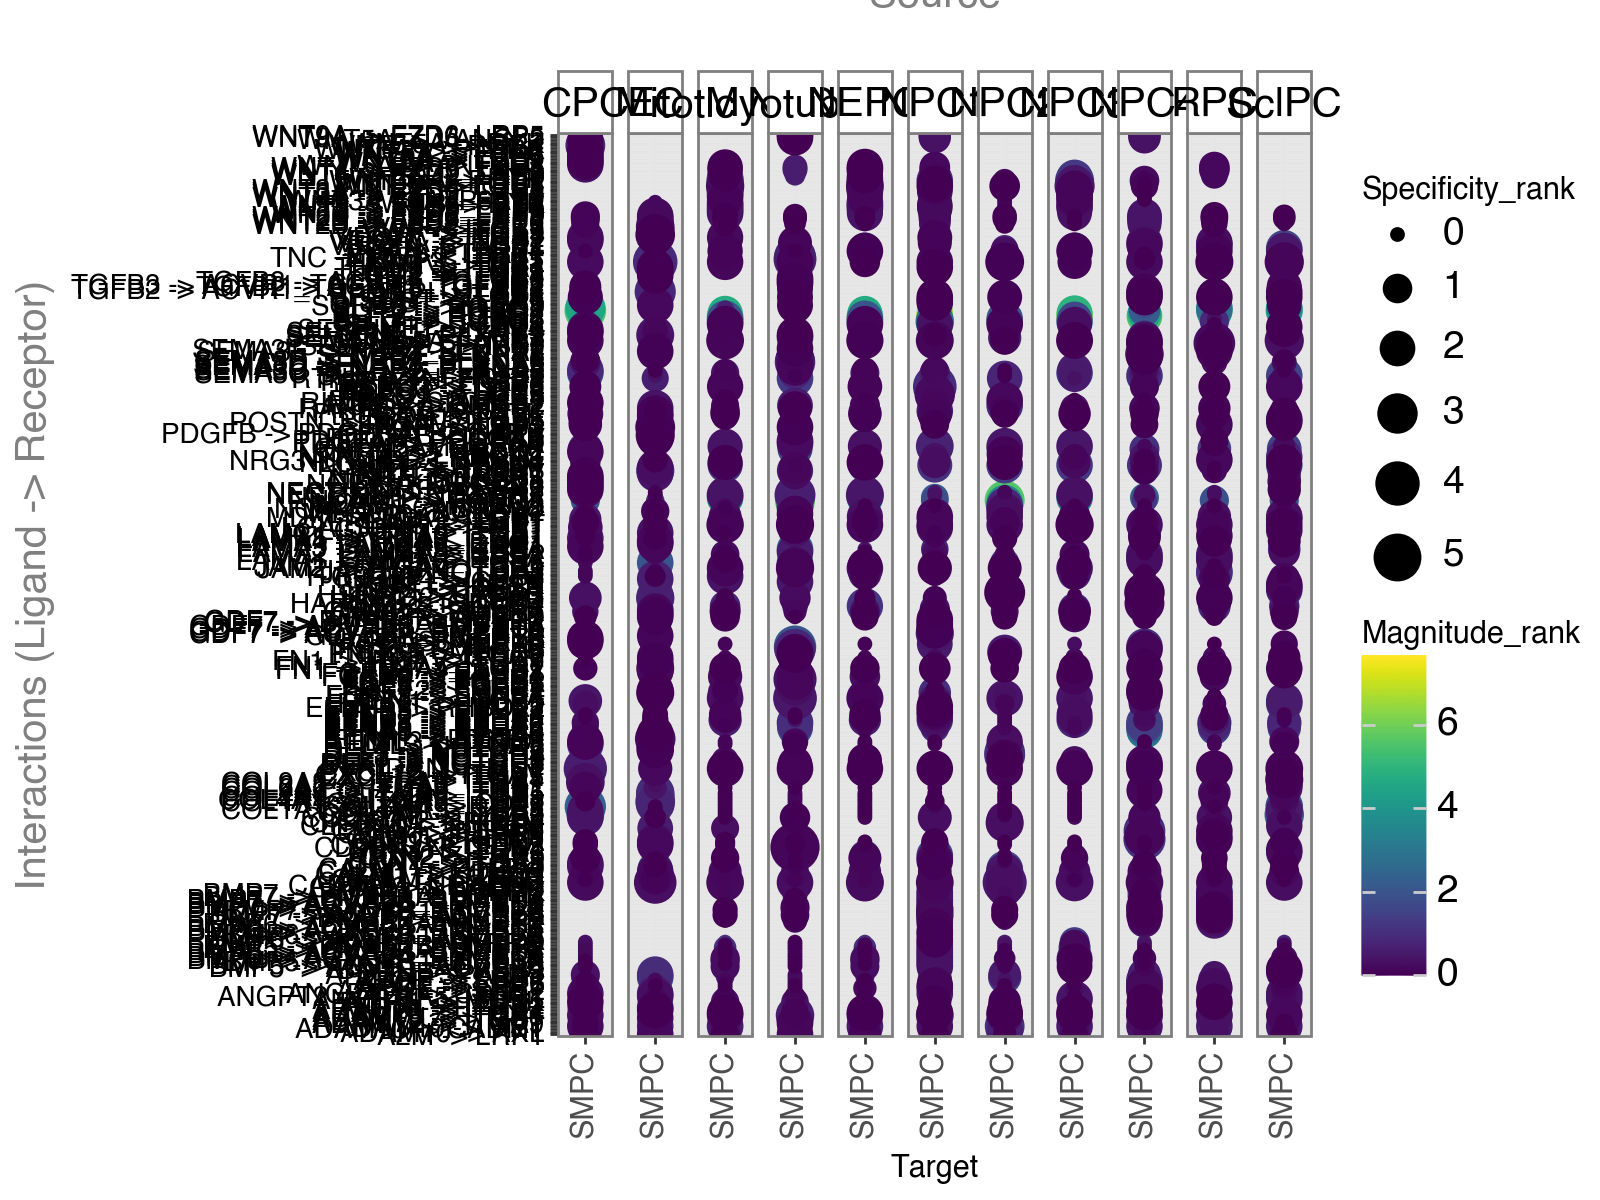

In [15]:
## we can also treat the ranks provided by RRA as a probability distribution to which we can filter interactions according to how 
## robustly and highly ranked they are across the different methods
my_plot = li.pl.dotplot(adata = adata, 
                        colour='magnitude_rank',
                        inverse_colour=True,
                        size='specificity_rank',
                        inverse_size=True,
                        source_labels=['SclPC', 'NPC1', 'NEPC', 'NPC2', 'CPC', 'Mitotic NPC', 'NPC3', 'RPC', 'NPC4', 'Myotubes', 'EC'],
                        target_labels=['SMPC'],
                        filter_fun=lambda x: x['specificity_rank'] <= 0.01,
                       )
my_plot

In [ ]:
#### We visualized the top globally robust ligand–receptor interactions 
# (RRA-based specificity ranking), and inspected which of these are active between selected sender and receiver cell types.

# Yes, your code is selecting the globally top 20 robust & highly ranked interactions
# The dotplot then shows only those that exist in your chosen cell-type context
# Fewer rows does not mean an error — it reflects biology + expression constraints

In [51]:
## loading packages
import liana as li
import scanpy as sc

In [52]:
adata = sc.read_h5ad("/Users/ogjaime/Desktop/CellRank/krabd28/LIANA/krabd28_LIANA.h5ad")

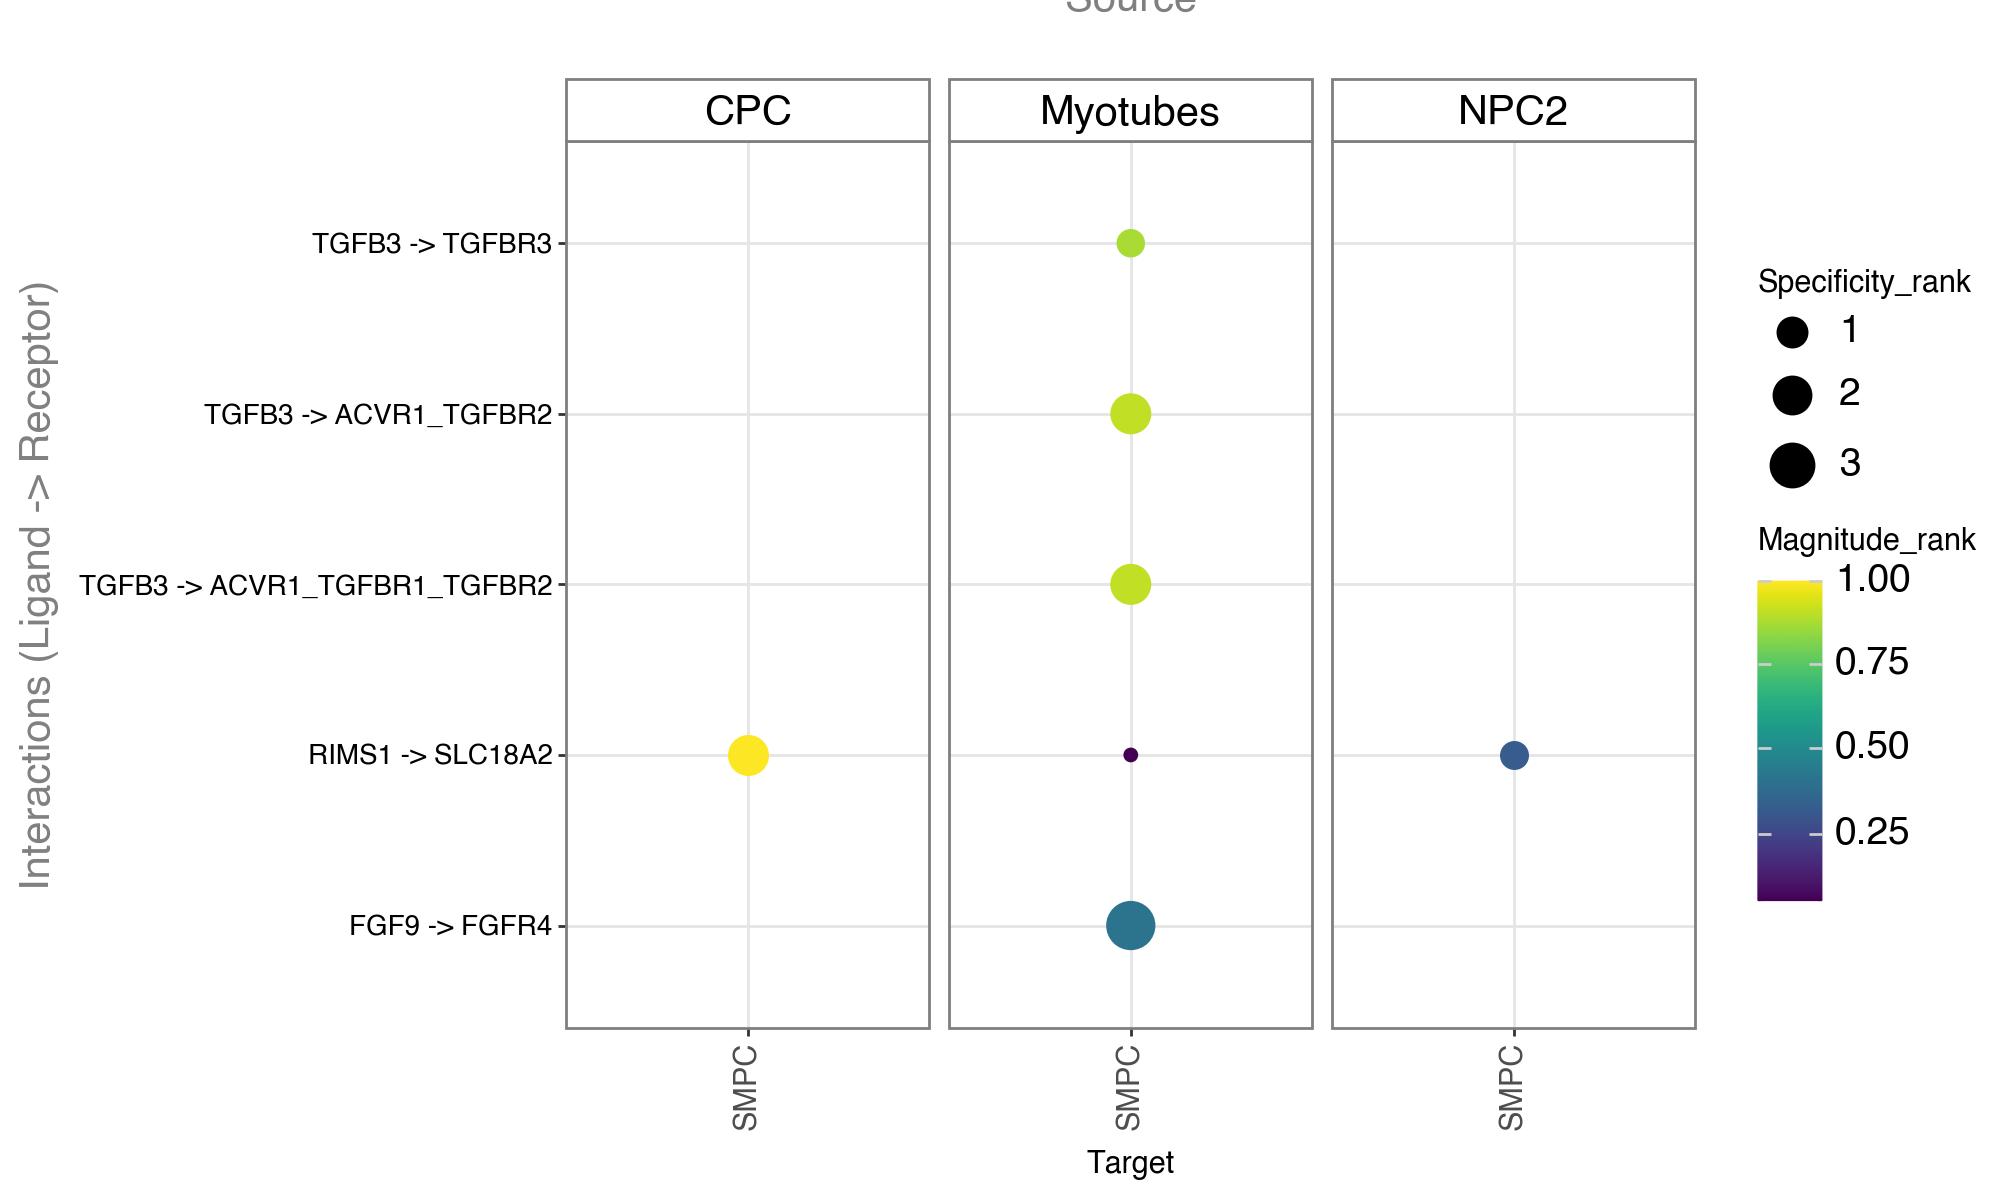

In [53]:
### limit the number of interactions (keep the top NUMBER of interactions) 
# -------------------------------
# Import plotting function
# -------------------------------
from liana.plotting import dotplot

# -------------------------------
# Access LIANA results (rank-based)
# -------------------------------
df = adata.uns['liana_res']  # or 'rank_aggregate' if that's what you just ran

# -------------------------------
# Filter significant interactions
# (e.g., specificity_rank ≤ 0.01)
# -------------------------------
df_sig = df[df['specificity_rank'] <= 0.01]

# -------------------------------
# Select top 20 interactions by magnitude_rank
# -------------------------------
top_df = df_sig.sort_values('magnitude_rank', ascending=False).head(20)

# -------------------------------
# Create a list of ligand_receptor strings for filtering
# -------------------------------
top_pairs = list(top_df['ligand_complex'] + "_" + top_df['receptor_complex'])

# -------------------------------
# Define source and target cell types
# -------------------------------
source_cells = ['SclPC', 'NPC1', 'NEPC', 'NPC2', 'CPC', 'Mitotic NPC', 'NPC3', 'RPC', 'NPC4', 'Myotubes', 'EC']
target_cells = ['SMPC']

# -------------------------------
# Plot dotplot
# -------------------------------
dotplot(
    adata=adata,
    colour='magnitude_rank',      # color by interaction strength
    size='specificity_rank',      # size by specificity
    inverse_size=True,            # smaller ranks → bigger dots
    source_labels=source_cells,
    target_labels=target_cells,
    figure_size=(10, 6),
    filter_fun=lambda row: (row['ligand_complex'] + "_" + row['receptor_complex']) in top_pairs,
    uns_key='liana_res'
)
## You limited the interaction types to 20, but the dotplot only shows those that actually exist for the chosen source–target pairs.
## If only 9 of those 20 actually occur between your specified sources and targets, you’ll see 9 rows.

In [54]:
adata = sc.read_h5ad("/Users/ogjaime/Desktop/CellRank/krabd28/LIANA/krabd28_LIANA.h5ad")

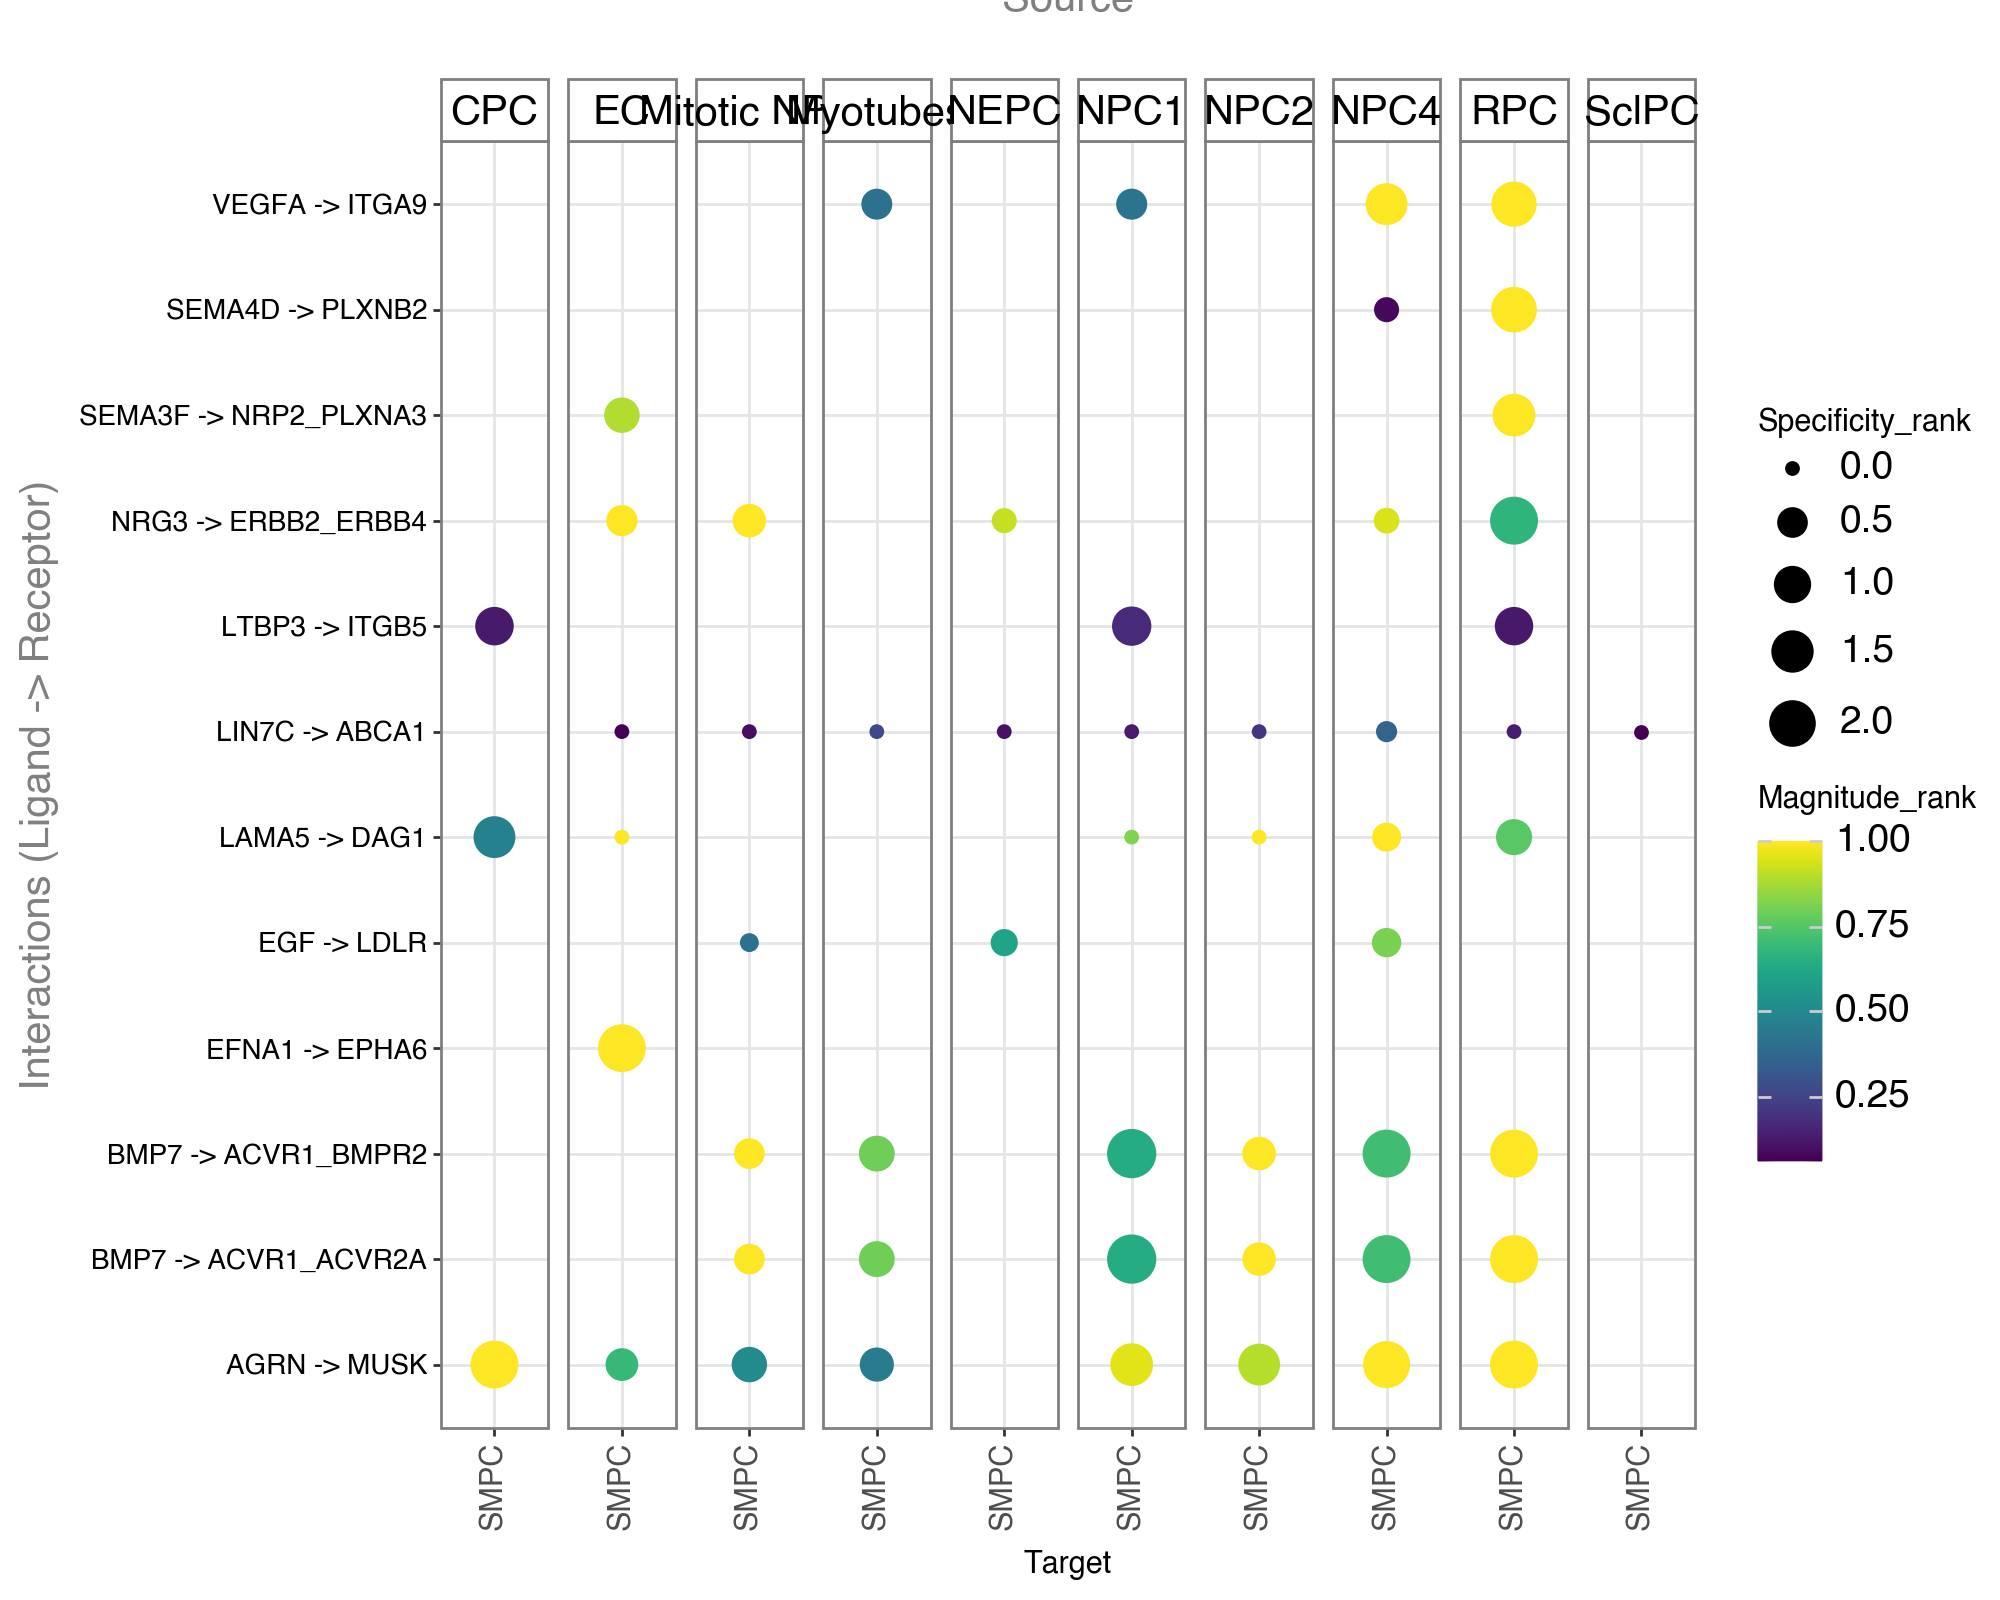

In [60]:
########## change p-value
### limit the number of interactions (keep the top NUMBER of interactions) 
# -------------------------------
# Import plotting function
# -------------------------------
from liana.plotting import dotplot

# -------------------------------
# Access LIANA results (rank-based)
# -------------------------------
df = adata.uns['liana_res']  # or 'rank_aggregate' if that's what you just ran

# -------------------------------
# Filter significant interactions
# (e.g., specificity_rank ≤ 0.01)
# -------------------------------
df_sig = df[df['specificity_rank'] <= 0.05]

# -------------------------------
# Select top 20 interactions by magnitude_rank
# -------------------------------
top_df = df_sig.sort_values('magnitude_rank', ascending=False).head(20)

# -------------------------------
# Create a list of ligand_receptor strings for filtering
# -------------------------------
top_pairs = list(top_df['ligand_complex'] + "_" + top_df['receptor_complex'])

# -------------------------------
# Define source and target cell types
# -------------------------------
source_cells = ['SclPC', 'NPC1', 'NEPC', 'NPC2', 'CPC', 'Mitotic NPC', 'NPC3', 'RPC', 'NPC4', 'Myotubes', 'EC']
target_cells = ['SMPC']

# -------------------------------
# Plot dotplot
# -------------------------------
dotplot(
    adata=adata,
    colour='magnitude_rank',      # color by interaction strength
    size='specificity_rank',      # size by specificity
    inverse_size=True,            # smaller ranks → bigger dots
    source_labels=source_cells,
    target_labels=target_cells,
    figure_size=(10, 8),
    filter_fun=lambda row: (row['ligand_complex'] + "_" + row['receptor_complex']) in top_pairs,
    uns_key='liana_res'
)
## You limited the interaction types to 20, but the dotplot only shows those that actually exist for the chosen source–target pairs.
## If only 9 of those 20 actually occur between your specified sources and targets, you’ll see 9 rows.

In [18]:
my_plot.save('/Users/ogjaime/Desktop/CellRank/krabd28/LIANA/dotplot.pdf')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/ogjaime/Desktop/CellRank/krabd28/LIANA/dotplot.pdf


In [19]:
# your top_pairs list is global
top_df = df_sig.sort_values('magnitude_rank', ascending=False).head(20)

In [20]:
top_df.head(20)

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
7406,EC,NEPC,EFNA1,EPHA6,0.260240,0.0,0.063909,0.627352,0.191363,0.048376,0.608576,0.022490,1.0
53597,RPC,RPC,VEGFA,TYRO3,0.215953,0.0,0.045704,0.356547,0.319103,0.029942,0.568000,0.006722,1.0
52873,RPC,NPC4,LTBP3,ITGB5,0.219980,0.0,0.038800,0.352771,0.278308,0.028227,0.547808,0.006722,1.0
53531,RPC,RPC,SEMA4D,PLXNB1,0.247091,0.0,0.055662,0.470220,0.353857,0.040648,0.592003,0.006722,1.0
53532,RPC,RPC,SEMA4D,PLXNB2,0.277181,0.0,0.074951,0.422288,0.341762,0.029838,0.627386,0.006722,1.0
53594,RPC,RPC,VEGFA,ITGB3,0.214535,0.0,0.045005,0.583282,0.398401,0.041041,0.566109,0.006722,1.0
53644,RPC,SMPC,AGRN,MUSK,0.247778,0.0,0.061343,0.333626,0.325866,0.019271,0.603686,0.006722,1.0
53527,RPC,RPC,SEMA3F,NRP2_PLXNA3,0.214957,0.0,0.043406,0.319557,0.168395,0.022727,0.561660,0.030870,1.0
24784,NEPC,NPC3,COL4A6,ITGA2_ITGB1,0.278707,0.0,0.076967,0.173633,0.210065,0.012484,0.630483,0.033153,1.0
53591,RPC,RPC,VEGFA,ITGA9,0.239072,0.0,0.057101,0.312838,0.281170,0.016568,0.595081,0.006722,1.0


In [ ]:
##### continue analysis

In [ ]:
# this one shows the ‘relevant’ interactions ordered to the magnitude_rank results from aggregated_rank.

In [2]:
## loading packages
# import liana
import liana as li
# needed for visualization and toy data
import scanpy as sc

In [3]:
adata = sc.read_h5ad("/Users/ogjaime/Desktop/CellRank/krabd28/krabd28_LIANA.h5ad")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


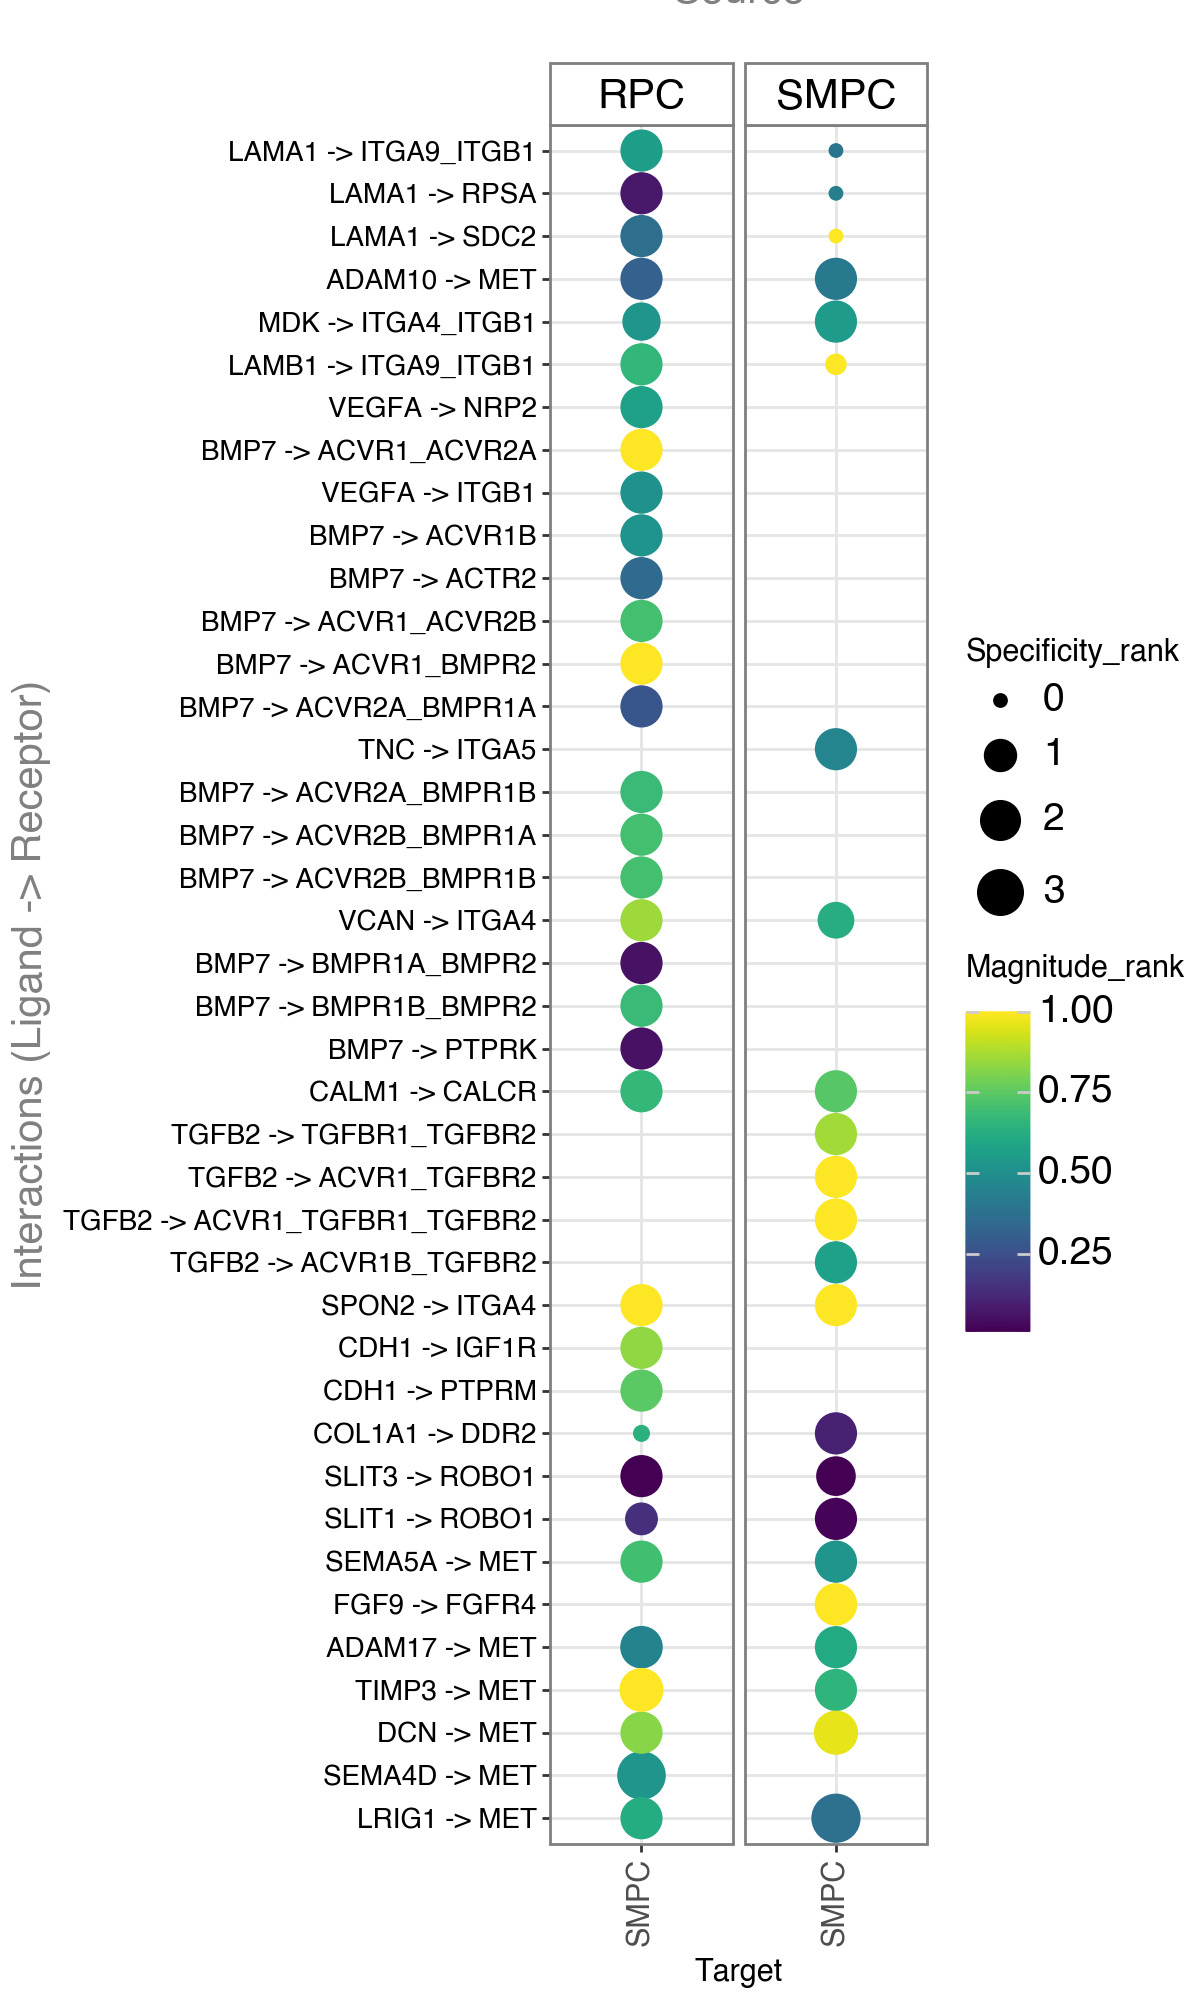

In [4]:
li.pl.dotplot(adata = adata, 
              colour='magnitude_rank',
              size='specificity_rank',
              inverse_size=True,
              inverse_colour=False,
              source_labels=['RPC', 'SMPC'],
              target_labels=['SMPC'],
              top_n=40, 
              orderby='specificity_rank',
              orderby_ascending=True,
              figure_size=(6, 10)
             )

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


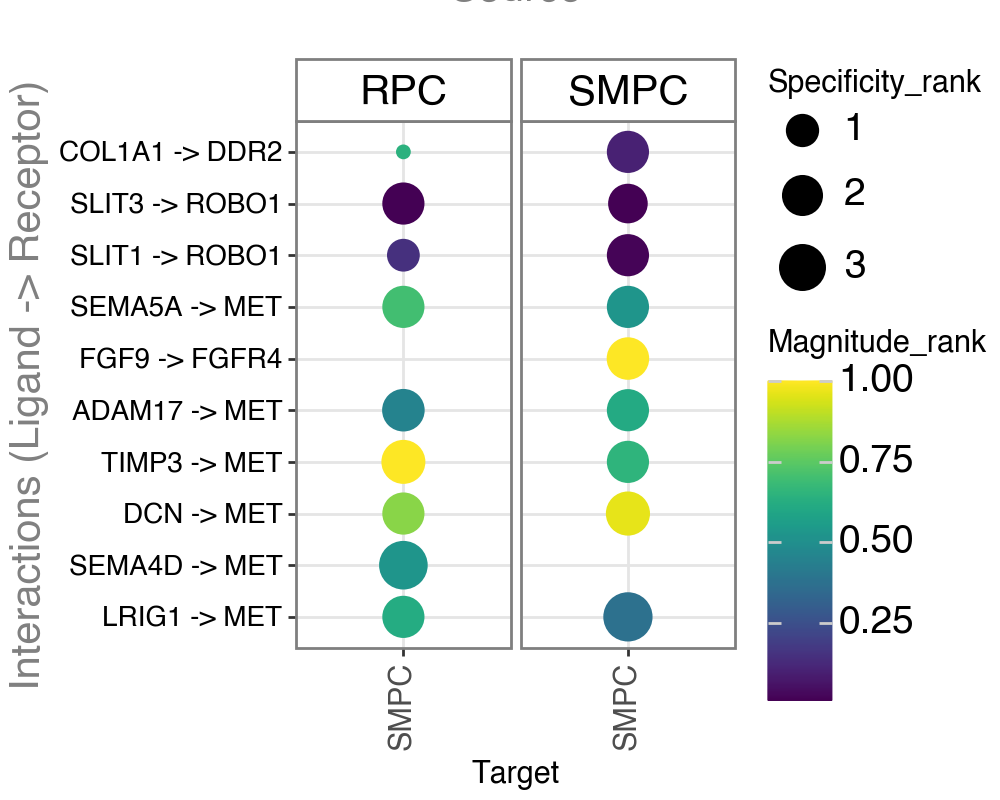

In [5]:
li.pl.dotplot(adata = adata, 
              colour='magnitude_rank',
              size='specificity_rank',
              inverse_size=True,
              inverse_colour=False,
              source_labels=['RPC', 'SMPC'],
              target_labels=['SMPC'],
              top_n=10, 
              orderby='specificity_rank',
              orderby_ascending=True,
              figure_size=(5,4)
             )

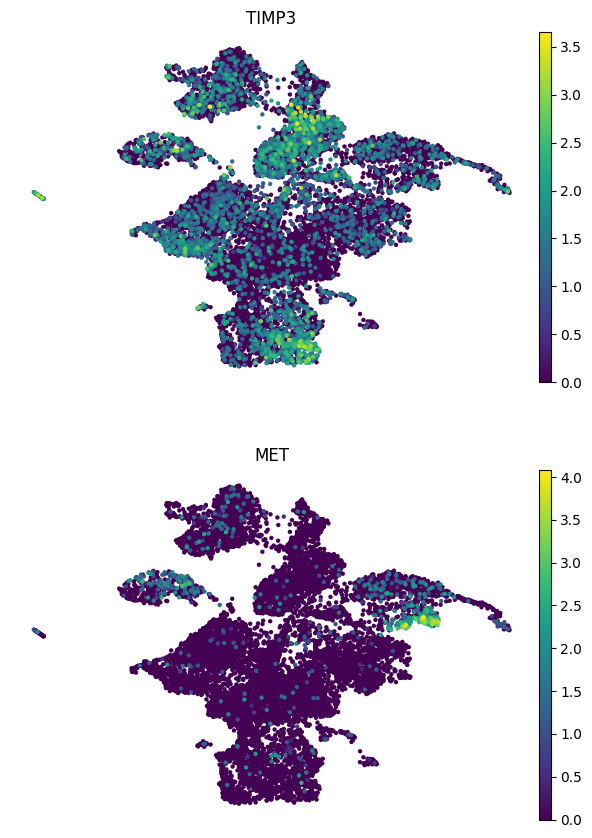

In [8]:
sc.pl.umap(adata, color=['TIMP3', 'MET'], frameon=False, legend_loc='on data', s=40, ncols=1)
import matplotlib.pyplot as plt

plt.rcParams['legend.fontsize'] = 20  

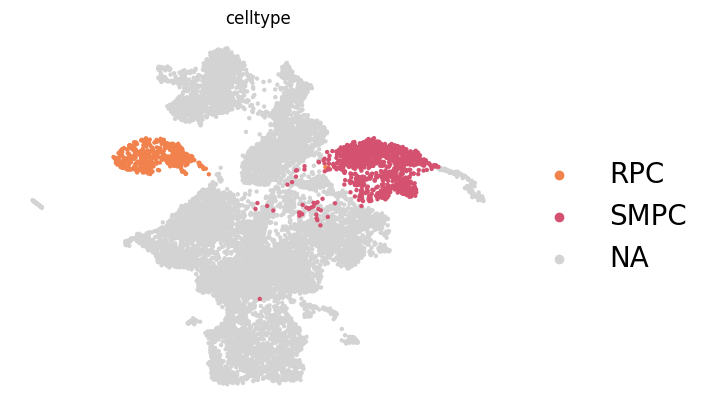

In [9]:
## outline cells of interest
ax = sc.pl.umap(
    adata,
    color="celltype",      # NOT a list
    groups=["SMPC", "RPC"],
    frameon=False,
    s=40,
    show=False
)
import matplotlib.pyplot as plt
plt.show()


In [10]:
# save analysis
adata.write("/Users/ogjaime/Desktop/CellRank/krabd28/LIANA/krabd28_LIANA.h5ad")

In [11]:
import liana as li

In [12]:
import scanpy as sc

In [13]:
adata = sc.read_h5ad("/Users/ogjaime/Desktop/CellRank/krabd28/LIANA/krabd28_LIANA.h5ad")

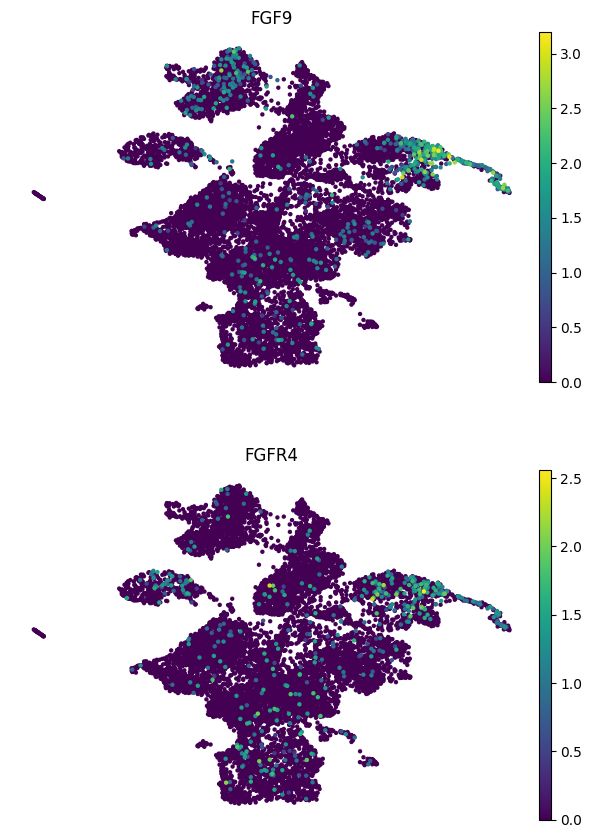

In [14]:
sc.pl.umap(adata, color=['FGF9', 'FGFR4'], frameon=False, legend_loc='on data', s=40, ncols=1)
import matplotlib.pyplot as plt

plt.rcParams['legend.fontsize'] = 20  

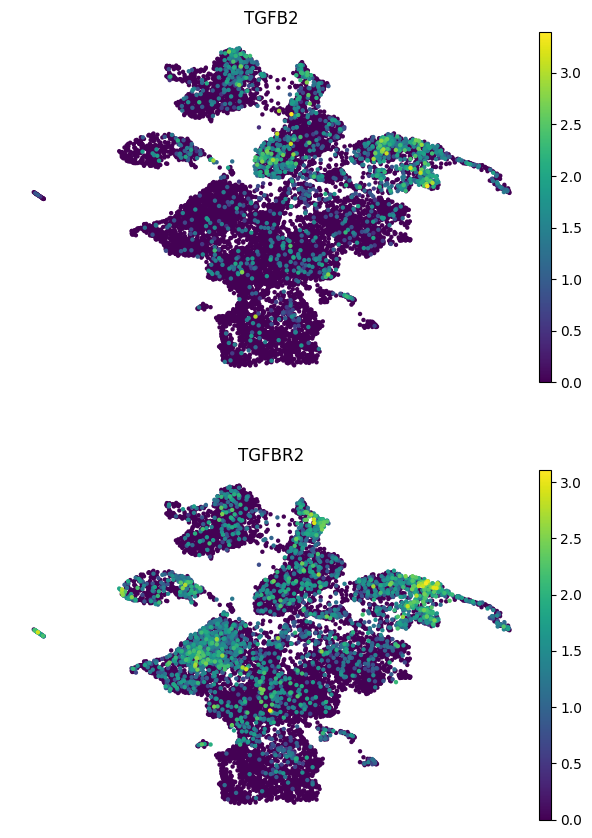

In [16]:
sc.pl.umap(adata, color=['TGFB2', 'TGFBR2'], frameon=False, legend_loc='on data', s=40, ncols=1)
import matplotlib.pyplot as plt

plt.rcParams['legend.fontsize'] = 20  